<a href="https://colab.research.google.com/github/saranya0207/Assignment2_DataScience/blob/main/WHR_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Factors Influencing Global Happiness: Analysis of the World Happiness Report (2011–2025)**

# 1.0 Introduction

The World Happiness Report (WHR) is one of the world's most influential cross-country studies on subjective well-being. Published annually since 2012, it ranks countries based on citizens' self-reported life evaluations using nationally representative survey data collected through the Gallup World Poll. In addition to ranking countries, the report examines several socio-economic factors that contribute to happiness, including GDP per capita, social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption (Helliwell et al. ,2024).

This project analyses the World Happiness Report 2026 dataset, which contains Life Evaluation (Cantril Ladder, three-year rolling average) together with its explanatory variables for 168 countries across 14 survey years (2011–2025). The dataset provides an opportunity to explore how economic, social, and institutional factors are associated with national well-being and how these relationships differ across countries and over time.

As an aspiring Data Scientist, analysing well-being indicators is highly relevant because governments, international organisations, researchers, and businesses increasingly rely on data-driven insights to evaluate quality of life, formulate public policies, support sustainable development goals, and guide investment decisions. Understanding these relationships is valuable for careers in policy analytics, ESG reporting, public health analytics, socio-economic consulting, and business intelligence.

The aim of this notebook is to perform a complete data analysis workflow, including data cleaning, exploratory data analysis (EDA), data visualization, and interpretation of findings. The analysis seeks to identify the factors most strongly associated with happiness, compare happiness levels among countries, and provide meaningful insights supported by existing literature and official World Happiness Report publications.

---
### **Dataset Source**

The dataset used in this project is obtained from the official World Happiness Report 2026.

Source:
https://worldhappiness.report/data-sharing/

Dataset:
WHR26_Data_Figure_2_1.xlsx

# 2.0 Problem Statement

National prosperity is often measured using economic indicators such as Gross Domestic Product (GDP). However, economic performance alone does not fully explain how people perceive their quality of life. Countries with similar levels of income frequently report different levels of happiness, suggesting that social support, health, personal freedom, generosity, and institutional trust also play important roles in shaping subjective well-being (Diener et al.,2018, Helliwell et al.,2024).

The World Happiness Report provides a comprehensive dataset for investigating these relationships. However, before meaningful analysis can be conducted, the raw dataset requires preprocessing. The dataset contains missing values, inconsistent country names, varying country coverage across survey years, and non-standardised column names. These issues must be addressed to ensure that the analysis is accurate, consistent, and reproducible.

This study aims to answer the following research questions:

1. Which countries have consistently recorded the highest and lowest levels of happiness between 2011 and 2025?

2. How has Malaysia's happiness score and global ranking changed over time, and how does it compare with other ASEAN countries?

3. Which socio-economic factors show the strongest relationship with life evaluation?

4. Is there a significant relationship between GDP per capita and happiness, and are there countries that deviate from this general trend? (De Neve & Sachs, 2020 and Diener et al., 2018)

5. How has global average happiness changed over time, and is there evidence of changes during the COVID-19 pandemic (2020–2021)?

To answer these questions, the raw dataset will first undergo data cleaning and preprocessing. Exploratory data analysis and statistical visualizations will then be performed to identify patterns, trends, and relationships within the data. Each visualization will be accompanied by an interpretation supported by findings from published reports and relevant literature.

# 3.0 Dataset Overview

Before analysis, the dataset was examined to understand its structure and identify potential data quality issues.

The following issues were identified:

- Missing values in several explanatory variables, particularly for survey years before 2019.
- Non-ASCII and inconsistent country names (e.g., Côte d'Ivoire, Türkiye, Hong Kong SAR of China).
- Uneven country coverage across survey years, resulting in an unbalanced panel dataset.
- No observations for the year 2013.
- Column names containing inconsistent prefixes (e.g., "Explained by:") and irregular formatting.

# 4.0 Setup & Imports

In [1]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)


In [2]:
# @title
# Load the raw dataset
# In Google Colab, upload WHR_Data.xlsx first, or mount Google Drive.
file = "WHR_Data.xlsx"

raw_df = pd.read_excel(file, sheet_name=0)
print("Raw shape:", raw_df.shape)
raw_df.head()


Raw shape: (2116, 13)


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


# 5.0 Data Cleaning

The data cleaning process follows a systematic workflow:

1. Inspect the dataset structure and identify potential data quality issues.
2. Remove redundant or unnecessary columns.
3. Standardise column names to improve readability and consistency.
4. Standardise country names to ensure consistent naming conventions.
5. Handle missing values using appropriate strategies.
6. Check and remove duplicate records, if any.
7. Validate the cleaned dataset by verifying data types, missing values, and summary statistics.

Each step is documented below to ensure that the analysis is transparent, reproducible, and aligned with best practices in data preprocessing.


## 5.1 Initial Inspection

In [3]:
# @title
raw_df.info()
print("\nMissing values per column:\n", raw_df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   object 
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by

## 5.2 Remove Empty Columns

The original Excel worksheet contains 28 columns. However, inspection of the dataset shows that only the first 13 columns contain meaningful information. The remaining columns are completely empty and appear to be artefacts from the original Excel export.

Since these empty columns do not contribute to the analysis, they are removed to simplify the dataset and improve readability.

In [4]:
# @title
# Keep only the first 13 columns, which contain the actual data
df = raw_df.iloc[:, :13].copy()
print("Trimmed shape:", df.shape)
df.head()


Trimmed shape: (2116, 13)


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


## 5.3 Standardise Column Names

In [5]:
# @title
df.columns = [
    "year", "rank", "country", "life_evaluation", "lower_whisker", "upper_whisker",
    "gdp_per_capita", "social_support", "healthy_life_expectancy",
    "freedom", "generosity", "corruption_perception", "dystopia_residual"
]
df.columns


Index(['year', 'rank', 'country', 'life_evaluation', 'lower_whisker', 'upper_whisker', 'gdp_per_capita', 'social_support',
       'healthy_life_expectancy', 'freedom', 'generosity', 'corruption_perception', 'dystopia_residual'],
      dtype='object')

## 5.4 Standardise Country Names

Country names in the raw dataset are not always represented using consistent naming conventions. Some countries use alternative spellings, official administrative names, or non-ASCII characters (for example, `Türkiye` and `Côte d'Ivoire`). These inconsistencies can create challenges when comparing the dataset with external sources or performing country-level analyses.

To improve consistency and reproducibility, selected country names are standardised to commonly recognised English names while preserving the underlying observations. This preprocessing step also ensures that future analyses, visualisations, and data merges can be performed without naming conflicts.

In [6]:
# @title
name_fixes = {
    "Côte d’Ivoire": "Ivory Coast",
    "Côte d'Ivoire": "Ivory Coast",
    "DR Congo": "DR Congo",
    "Congo": "Congo (Brazzaville)",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
    "Türkiye": "Turkey",
    "Republic of Korea": "South Korea",
    "Republic of Moldova": "Moldova",
    "Russian Federation": "Russia",
    "Hong Kong SAR of China": "Hong Kong",
    "Taiwan Province of China": "Taiwan",
    "State of Palestine": "Palestine",
}
df["country"] = df["country"].replace(name_fixes)
df["country"] = df["country"].str.strip()

# Confirm no more odd-character names remain
odd = df[df["country"].str.contains(r"[^\x00-\x7F]", regex=True)]
print("Remaining non-ASCII country names:", odd["country"].unique())


Remaining non-ASCII country names: []


## 5.5 Check for Duplicates and Structural Validity

After cleaning the column names and country labels, the dataset is checked for duplicate records and overall structural consistency.

In [7]:
# @title
dupes = df.duplicated(subset=["year", "country"]).sum()
print("Duplicate (year, country) rows:", dupes)

print("\nYears covered:", sorted(df['year'].unique()))
print("\nCountries surveyed per year:")
print(df.groupby("year")["country"].nunique())


Duplicate (year, country) rows: 0

Years covered: [np.int64(2011), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Countries surveyed per year:
year
2011    156
2012    156
2014    158
2015    157
2016    155
2017    156
2018    156
2019    153
2020    149
2021    146
2022    137
2023    143
2024    147
2025    147
Name: country, dtype: int64


**Observation:**

The year 2013 is absent from the consolidated Figure 2.1 dataset, and the number of countries surveyed varies across years because participation in the Gallup World Poll differs by survey cycle. These characteristics reflect the structure of the official World Happiness Report dataset rather than data quality issues. Consequently, no attempt is made to fabricate or interpolate missing country-year observations, as doing so could distort the original data and bias subsequent analyses. (World Happiness Report, 2026)

## 5.6 Handle Missing Values

In [8]:
# @title
missing_pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print(missing_pct)


dystopia_residual          52.1
healthy_life_expectancy    52.0
freedom                    51.9
corruption_perception      51.9
gdp_per_capita             51.8
generosity                 51.8
social_support             51.8
lower_whisker              51.7
upper_whisker              51.7
life_evaluation             0.0
country                     0.0
rank                        0.0
year                        0.0
dtype: float64


In [9]:
# @title
# The percentage of missing values for each survey year is calculated using the `gdp_per_capita` variable as a representative example.
missing_by_year = df.groupby("year")["gdp_per_capita"].apply(lambda s: s.isna().mean() * 100)
print(missing_by_year)


year
2011    100.000000
2012    100.000000
2014    100.000000
2015    100.000000
2016    100.000000
2017    100.000000
2018    100.000000
2019      0.000000
2020      0.000000
2021      0.000000
2022      0.000000
2023      2.097902
2024      0.000000
2025      0.000000
Name: gdp_per_capita, dtype: float64


Missing values in this dataset are not random. The core variables (`year`, `country`, `rank`, and `life_evaluation`) are complete and are sufficient for analysing historical happiness trends across all survey years. In contrast, the explanatory variables (GDP per capita, social support, healthy life expectancy, freedom, generosity, perceptions of corruption, and the dystopia residual) are primarily available only for the more recent survey years.

Because this pattern reflects the reporting structure of the official dataset rather than missing observations caused by data quality issues, missing values are not imputed. Imputing socio-economic indicators across multiple years would introduce artificial information and could bias the analysis.

Instead, two datasets are maintained:

- `df`: the complete panel dataset used for analyses involving happiness scores, rankings, and long-term trends.
- `df_factors`: a subset containing only observations with complete explanatory variables. This dataset is used for analyses that investigate the relationships between happiness and its explanatory factors.

This approach preserves the integrity of the original data while ensuring that each analysis uses the most appropriate set of observations.

In [10]:
# @title
factor_cols = ["gdp_per_capita", "social_support", "healthy_life_expectancy",
               "freedom", "generosity", "corruption_perception", "dystopia_residual"]

df_factors = df.dropna(subset=factor_cols).copy()
print("Full panel (life evaluation focus):", df.shape)
print("Factors-rich subset (2019-2025):", df_factors.shape)
print("Years in factors-rich subset:", sorted(df_factors['year'].unique()))


Full panel (life evaluation focus): (2116, 13)
Factors-rich subset (2019-2025): (1013, 13)
Years in factors-rich subset: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


**Observation:**

The factors-rich subset contains only the survey years with complete explanatory variables. This subset is used for correlation and regression analyses, while the complete panel is retained for trend analyses involving happiness scores and rankings. By separating the datasets according to their intended purpose, the analysis avoids unnecessary data loss while preventing biased estimates that could result from imputing systematically missing values.

In [11]:
# @title
# Final sanity checks
assert df['life_evaluation'].between(0, 10).all(), "Life evaluation out of expected Cantril Ladder range!"
assert df['rank'].min() >= 1
assert df_factors[factor_cols].isna().sum().sum() == 0
print("✅ All validity checks passed.")
df.describe(include="all").T


✅ All validity checks passed.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,2116.0,NaN,NaN,NaN,2018.220227,4.249844,2011.0,2015.0,2018.0,2022.0,2025.0
rank,2116.0,NaN,NaN,NaN,76.190926,43.845101,1.0,38.0,76.0,114.0,158.0
country,2116,168,Finland,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
life_evaluation,2116.0,NaN,NaN,NaN,5.465655,1.12387,1.364,4.60475,5.48,6.32125,7.856
lower_whisker,1022.0,NaN,NaN,NaN,5.436091,1.140959,1.301,4.619707,5.592631,6.29011,7.78
upper_whisker,1022.0,NaN,NaN,NaN,5.664733,1.107424,1.427,4.86775,5.812,6.4865,7.904
gdp_per_capita,1019.0,NaN,NaN,NaN,1.26567,0.463823,0.0,0.944,1.304,1.636,2.209
social_support,1019.0,NaN,NaN,NaN,1.096746,0.357642,0.0,0.865,1.140119,1.382,1.84
healthy_life_expectancy,1016.0,NaN,NaN,NaN,0.553435,0.22998,0.0,0.38975,0.5605,0.712325,1.238
freedom,1017.0,NaN,NaN,NaN,0.609465,0.21207,0.0,0.471,0.602,0.735,1.147


# 6.0 Results & Discussion

## 6.1 Visualization 1 — The Happiest & Least Happy Countries in 2025

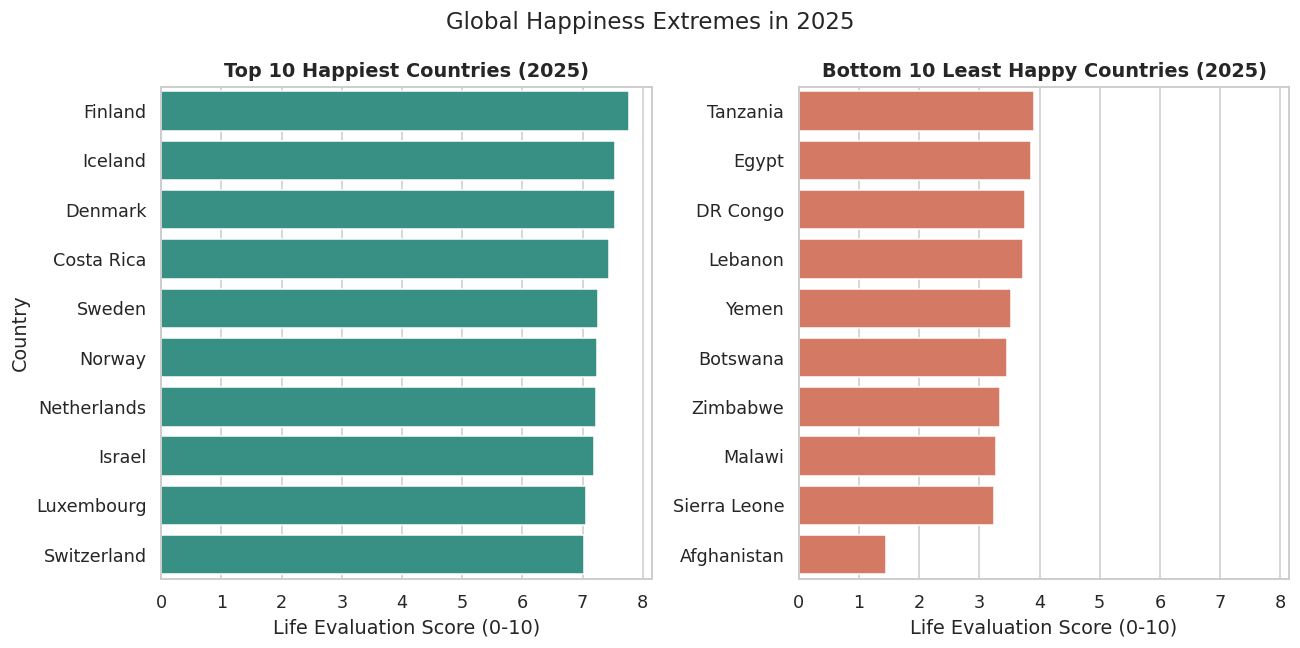

In [12]:
# @title
latest = df[df["year"] == df["year"].max()].sort_values("life_evaluation", ascending=False)

top10 = latest.head(10)
bottom10 = latest.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

sns.barplot(data=top10, y="country", x="life_evaluation", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Top 10 Happiest Countries (2025)")
axes[0].set_xlabel("Life Evaluation Score (0-10)")
axes[0].set_ylabel("Country")

sns.barplot(data=bottom10, y="country", x="life_evaluation", ax=axes[1], color="#e76f51")
axes[1].set_title("Bottom 10 Least Happy Countries (2025)")
axes[1].set_xlabel("Life Evaluation Score (0-10)")
axes[1].set_ylabel("")

plt.suptitle("Global Happiness Extremes in 2025", fontsize=15)
plt.tight_layout()
plt.show()


**Insight:**

Finland ranks first in the 2025 World Happiness Report with a life evaluation score while Afghanistan records the lowest score. The countries occupying the highest positions are predominantly Nordic and Western European nations, whereas the lowest-ranked countries are generally affected by armed conflict, political instability, or prolonged economic crises.

This pattern is consistent with previous research showing that happiness is influenced by more than economic prosperity alone. Social support, institutional trust, freedom to make life choices, and perceived fairness have been identified as some of the strongest determinants of subjective well-being (Helliwell et al., 2024; Diener, Oishi, & Tay, 2018). Conversely, exposure to conflict, weak governance, and economic insecurity are associated with substantially lower life satisfaction and overall well-being (De Neve & Sachs, 2020; Clark et al., 2018).

Overall, the findings suggest that long-term investments in social cohesion, effective public institutions, healthcare, and political stability may contribute more to national happiness than economic growth alone.


## 6.2 Visualization 2 — Malaysia's Happiness Trajectory vs ASEAN Neighbours

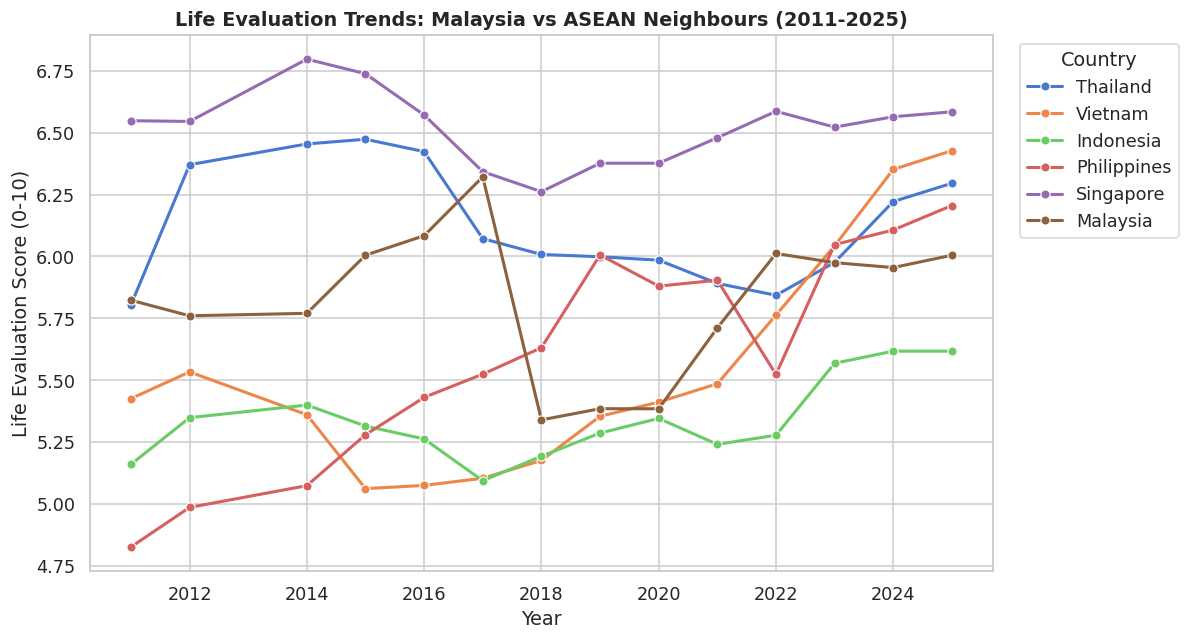

In [13]:
# @title
asean = ["Malaysia", "Singapore", "Thailand", "Philippines", "Indonesia", "Vietnam"]
asean_df = df[df["country"].isin(asean)].sort_values("year")

plt.figure(figsize=(11, 6))
sns.lineplot(data=asean_df, x="year", y="life_evaluation", hue="country", marker="o", linewidth=2)
plt.title("Life Evaluation Trends: Malaysia vs ASEAN Neighbours (2011-2025)")
plt.xlabel("Year")
plt.ylabel("Life Evaluation Score (0-10)")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [14]:
# @title
my = df[df["country"] == "Malaysia"][["year", "rank", "life_evaluation"]].sort_values("year")
my


,year,rank,life_evaluation
2010,2011,51,5.8230
1859,2012,56,5.7600
1706,2014,61,5.7700
1535,2015,47,6.0050
1375,2016,42,6.0840
1212,2017,35,6.3220
1101,2018,80,5.3390
950,2019,82,5.3843
800,2020,81,5.3840
643,2021,70,5.7110


**Insight:**

Malaysia's life evaluation score increased from 5.82 in 2011 to a peak of 6.32 in 2017 before declining during the period surrounding the COVID-19 pandemic and subsequently recovering to 6.01 in 2025. Within ASEAN, Singapore consistently records the highest life evaluation scores, while the Philippines and Vietnam exhibit greater year-to-year variation. Malaysia's 2025 global ranking of 71st places it in the middle of the global distribution, behind Singapore but ahead of Indonesia and the Philippines.

The gradual recovery observed after the pandemic is consistent with broader evidence that improvements in subjective well-being have been uneven across East Asia and the Pacific as countries experienced different rates of economic recovery, labour market adjustment, and social adaptation following COVID-19 (World Bank, 2023). Furthermore, research suggests that national well-being is influenced not only by economic conditions but also by social support, institutional trust, health, and personal freedom, which may explain why countries with comparable income levels can report different happiness outcomes (Diener, Oishi, & Tay, 2018; Helliwell et al., 2024).

From a policy and business perspective, Malaysia's relatively stable position suggests that it remains a moderately attractive environment for quality of life and talent retention within Southeast Asia (Yuen & Chu, 2015). However, the slower post-pandemic recovery indicates that continued improvements in public well-being are likely to depend on both economic resilience and broader social factors.


## 6.3 Visualization 3 — Which Factor Explains Happiness Most in 2019–2025

/tmp/ipykernel_1937/3229192787.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=factor_long, x="contribution", y="factor", order=order, palette="crest")


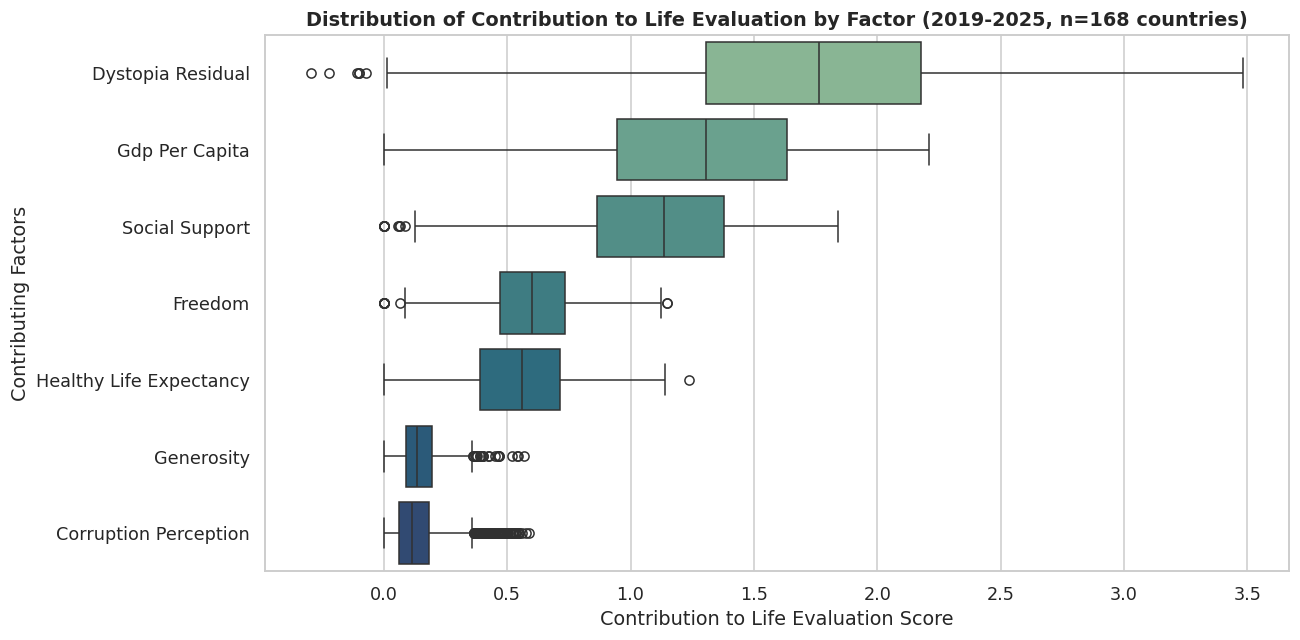

In [15]:
# @title
factor_long = df_factors.melt(
    id_vars=["country", "year"],
    value_vars=factor_cols,
    var_name="factor",
    value_name="contribution"
)
factor_long["factor"] = factor_long["factor"].str.replace("_", " ").str.title()

plt.figure(figsize=(12, 6))
order = factor_long.groupby("factor")["contribution"].median().sort_values(ascending=False).index
sns.boxplot(data=factor_long, x="contribution", y="factor", order=order, palette="crest")
plt.title("Distribution of Contribution to Life Evaluation by Factor (2019-2025, n=168 countries)")
plt.xlabel("Contribution to Life Evaluation Score")
plt.ylabel("Contributing Factors")
plt.tight_layout()
plt.show()


**Insight:**

The boxplots indicate that the largest median contributions to life evaluation are associated with the **Dystopia + residual** component and **Log GDP per capita**, followed by **Healthy Life Expectancy** and **Social Support**. Among the measured explanatory variables, GDP per capita, healthy life expectancy, and social support consistently exhibit relatively high contributions across countries, whereas **Generosity** has the lowest median contribution and the greatest relative variability, suggesting that its influence is comparatively small and differs substantially between countries.

It is important to note that the **Dystopia + residual** term should not be interpreted as a direct determinant of happiness. Instead, it represents the portion of life evaluation that remains unexplained after accounting for the measured explanatory variables, capturing influences that are not explicitly included in the model (Helliwell et al., 2024).

Overall, these findings are consistent with previous research showing that income, social relationships, and health are among the strongest predictors of subjective well-being. Numerous cross-country studies have found that higher income improves life evaluation primarily by increasing material security, while strong social support and better health contribute independently to higher levels of happiness (Diener, Oishi, & Tay, 2018; Helliwell et al., 2024). In contrast, generosity tends to have a weaker and more context-dependent association with national happiness, reflecting cultural and institutional differences across countries.


## 6.4 Visualization 4 — GDP vs Life Evaluation

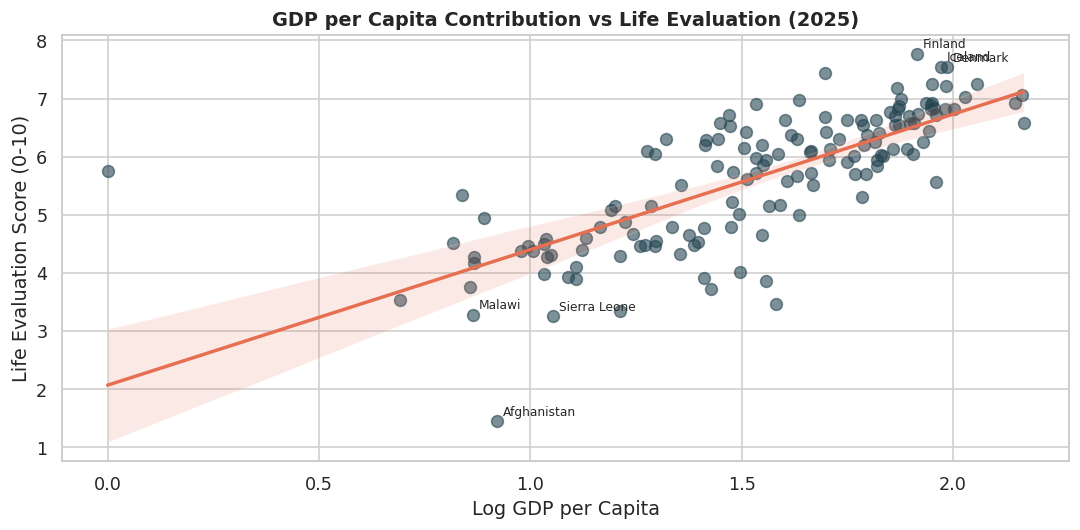

Pearson correlation (GDP contribution vs life evaluation): 0.75


In [16]:
# @title
latest_factors = df_factors[df_factors["year"] == df_factors["year"].max()]

plt.figure(figsize=(10, 5))
sns.regplot(
    data=latest_factors, x="gdp_per_capita", y="life_evaluation",
    scatter_kws={"alpha": 0.6, "s": 60, "color": "#264653"},
    line_kws={"color": "#e76f51"}
)

for _, row in latest_factors.nlargest(3, "life_evaluation").iterrows():
    plt.annotate(row["country"], (row["gdp_per_capita"], row["life_evaluation"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
for _, row in latest_factors.nsmallest(3, "life_evaluation").iterrows():
    plt.annotate(row["country"], (row["gdp_per_capita"], row["life_evaluation"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.title(f"GDP per Capita Contribution vs Life Evaluation ({int(latest_factors['year'].iloc[0])})")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Evaluation Score (0-10)")
plt.tight_layout()
plt.show()

corr = latest_factors["gdp_per_capita"].corr(latest_factors["life_evaluation"])
print(f"Pearson correlation (GDP contribution vs life evaluation): {corr:.2f}")


**Insight:**

The scatter plot shows a strong positive association between the contribution of **Log GDP per capita** and overall life evaluation, indicating that countries with larger GDP contributions generally report higher happiness scores. However, the relationship is not perfectly linear, with several countries lying noticeably above or below the fitted regression line. This suggests that economic prosperity alone does not fully explain differences in subjective well-being.

Countries positioned above the regression line achieve higher life evaluation than would be expected based on GDP contribution alone, implying that other factors such as social support, healthy life expectancy, freedom to make life choices, and institutional trust also play important roles. Conversely, countries below the regression line appear to receive relatively smaller happiness outcomes despite stronger economic contributions, highlighting the importance of considering multiple dimensions of well-being rather than income alone.

These findings are consistent with previous research showing that income is a significant predictor of life satisfaction but does not fully determine subjective well-being. Beyond material living standards, social relationships, physical health, personal freedom, and trust in public institutions make substantial independent contributions to happiness (Diener, Oishi, & Tay, 2018; Helliwell et al., 2024). This broader perspective also aligns with the Easterlin paradox, which argues that increases in income alone do not necessarily translate into proportional increases in long-term happiness once basic needs have been met (Easterlin, 1974; Easterlin et al., 2010).


## 6.5 Visualization 5 — Global Average Happiness Over Time & COVID-19

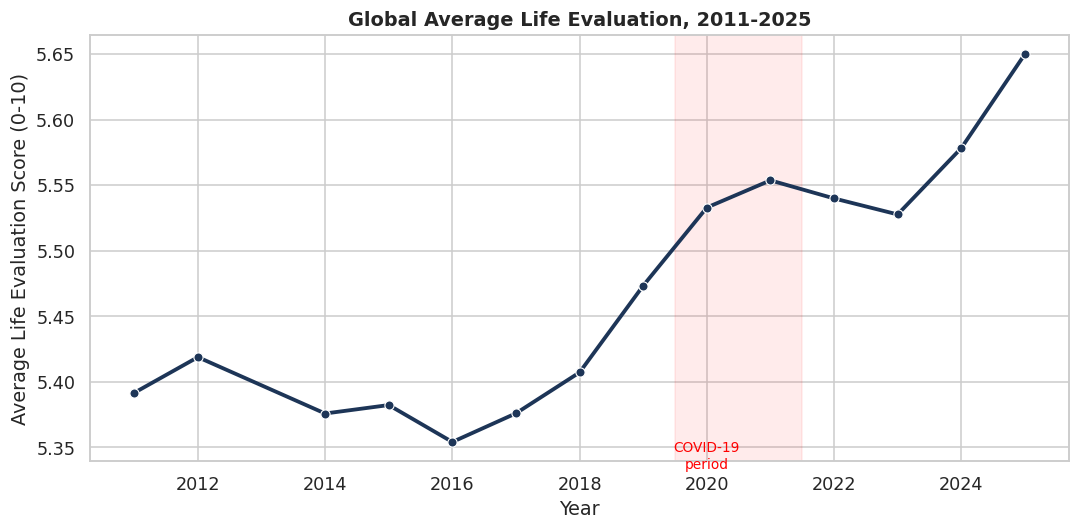

,year,life_evaluation
0,2011,5.391538
1,2012,5.418731
2,2014,5.375741
3,2015,5.382185
4,2016,5.354019
5,2017,5.375878
6,2018,5.407096
7,2019,5.473240
8,2020,5.532839
9,2021,5.553575


In [17]:
# @title
yearly_avg = df.groupby("year")["life_evaluation"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_avg, x="year", y="life_evaluation", marker="o", linewidth=2.5, color="#1d3557")
plt.axvspan(2019.5, 2021.5, color="red", alpha=0.08)
plt.text(2020, yearly_avg["life_evaluation"].min() - 0.02, "COVID-19\nperiod", ha="center", color="red", fontsize=9)

plt.title("Global Average Life Evaluation, 2011-2025")
plt.xlabel("Year")
plt.ylabel("Average Life Evaluation Score (0-10)")
plt.tight_layout()
plt.show()

yearly_avg


**Insight:**

The global average life evaluation remained relatively stable at around **5.3–5.4** throughout much of the study period, with a modest decline observed during **2019–2021**, followed by a gradual recovery between **2022 and 2025**. Although the downturn coincides with the COVID-19 pandemic, the overall change is smaller than might be expected given the scale of the global crisis. This suggests that average happiness levels remained comparatively resilient despite widespread disruptions.

This observation is consistent with the findings of the *World Happiness Report 2022*, which reported that acts of benevolence, social trust, and confidence in public institutions increased in many countries during the pandemic and may have partially offset the negative effects of COVID-19 on subjective well-being (Helliwell et al., 2022). Consequently, changes in happiness cannot be explained solely by economic or public health shocks, as social cohesion and institutional resilience also contribute to how populations respond to crises.

It is also important to note that the global average masks substantial differences between countries. While some countries experienced noticeable declines in life evaluation during the pandemic, others remained relatively stable or recovered more quickly. Therefore, aggregate indicators should be interpreted with caution, as they may conceal considerable country-level variation in well-being.


## 6.6 Visualization 6 — Correlation Heatmap of All Explanatory Factors

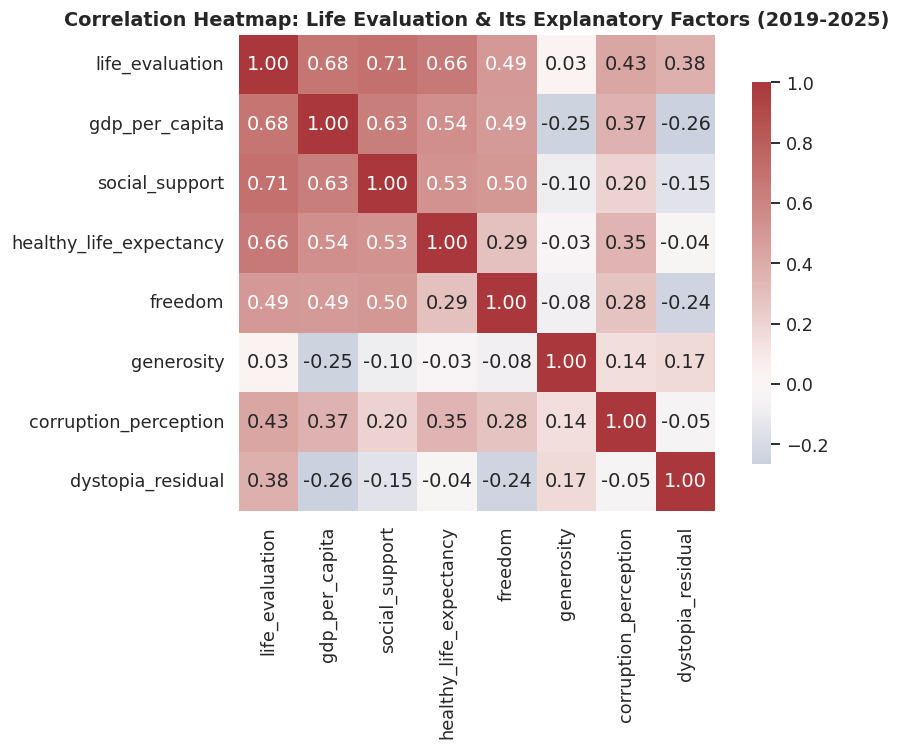

In [18]:
# @title
corr_matrix = df_factors[["life_evaluation"] + factor_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap: Life Evaluation & Its Explanatory Factors (2019-2025)")
plt.tight_layout()
plt.show()


**Insight:**

Life evaluation correlates most strongly with GDP per capita (≈0.8), healthy life expectancy, and social support, while generosity and perceptions of corruption show the weakest correlations with overall happiness. Notably, GDP per capita and healthy life expectancy are themselves highly correlated (indicating potential multicollinearity), which is expected since wealthier nations typically have better healthcare systems. This is an important consideration when using these variables in a regression model, as the estimated effect of GDP may partially overlap with that of healthy life expectancy.


# 7.0 Conclusion

This project analysed the World Happiness Report 2026 dataset covering 168 countries between 2011 and 2025. After cleaning and validating the data, exploratory data analysis was performed to examine global happiness patterns, compare Malaysia with ASEAN countries, and investigate the relationship between life evaluation and its explanatory factors.

### Key Findings

* Nordic countries, particularly Finland, Iceland, and Denmark, consistently ranked among the happiest countries, while countries affected by prolonged conflict or political instability, such as Afghanistan, Yemen, and Lebanon, recorded the lowest life evaluation scores.

* Malaysia's life evaluation recovered gradually following the COVID-19 period, increasing from approximately 5.34 to 6.01 by 2025. Within ASEAN, Malaysia remains a moderately happy country, ranking behind Singapore but ahead of Indonesia and the Philippines.

* Among the explanatory variables, Log GDP per capita, Healthy Life Expectancy, and Social Support showed the strongest association with life evaluation. In contrast, Generosity and Perceptions of Corruption displayed greater variability across countries.

* A positive relationship was observed between the GDP contribution and life evaluation. However, countries with similar economic contributions often reported different happiness levels, suggesting that social and institutional factors also play important roles in subjective well-being.

* Global average life evaluation remained relatively stable throughout the study period. Although a modest decline was observed during the COVID-19 years, the overall trend indicates a gradual recovery after 2021, while country-level differences remained substantial.

### Practical Implications

* Policymakers should complement economic growth strategies with investments in healthcare, social support systems, and institutional trust to improve national well-being (De Neve & Sachs, 2020 and World Bank, 2023).

* Businesses and investors may consider well-being indicators alongside conventional economic metrics when assessing labour markets, talent attraction, and investment environments.

* International organisations and development agencies should evaluate country-level trends rather than relying solely on global averages, as aggregate measures can mask important regional differences.


# 8.0 References

1. Clark, A. E., Fleche, S., Layard, R., Powdthavee, N., & Ward, G. (2018). *The origins of happiness: The science of well-being over the life course*. Princeton University Press.

2. Carlsen, L. (2018). Happiness as a sustainability factor. *Sustainability Science, 13*(2), 549–571.

3. Boo, M. C., Yen, S. H., & Lim, H. E. (2016). A note on happiness and life satisfaction in Malaysia. *Malaysian Journal of Economic Studies, 53*(2), 261–277.

4. De Neve, J.-E., & Sachs, J. D. (2020). The SDGs and human well-being: A global analysis of synergies, trade-offs, and regional differences. *Scientific Reports, 10*, 15113.

5. Diener, E., Suh, E. M., Lucas, R. E., & Smith, H. L. (1999). Subjective well-being: Three decades of progress. *Psychological Bulletin, 125*(2), 276–302.

6. Diener, E., Oishi, S., & Tay, L. (2018). Advances in subjective well-being research. *Nature Human Behaviour, 2*(4), 253–260.

7. Handayani, D. O. D., Lubis, M., & Lubis, A. R. (2022). Prediction analysis of the happiness ranking of countries based on macro level factors. *IAES International Journal of Artificial Intelligence, 11*(2), 666.

8. Helliwell, J. F., Huang, H., & Wang, S. (2019). Changing world happiness. *World Happiness Report 2019* (Chapter 2), 11–46.

9. Helliwell, J. F., Huang, H., Norton, M., Goff, L., & Wang, S. (2023). World happiness, trust and social connections in times of crisis. In *World Happiness Report 2023*.

10. Helliwell, J. F., Layard, R., Sachs, J. D., De Neve, J.-E., Aknin, L. B., & Wang, S. (Eds.). (2024). *World Happiness Report 2024*. Sustainable Development Solutions Network.

11. World Bank. (2023). *East Asia and Pacific Economic Update: Reviving Growth*. World Bank.

12. Yuen, T. W. K., & Chu, W. W. L. (2015). Happiness in ASEAN member states. *International Journal of Happiness and Development, 2*(1), 69–83.
